In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def extract_data(filedir):
    files = os.listdir(filedir)
    df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
    df_list = [df.drop(0) for df in df_list]
    df_list = [df.drop(df.columns[list(range(-1, -9, -1))], axis=1) for df in df_list]
    data = pd.concat(df_list, ignore_index=True)    
    return data


dir1 = "F:/IMU_computational_ethology/Data/LSD/5d"
dir2 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data2_e8"


data1 = extract_data(dir1)
data2 = extract_data(dir2)

print(data1.shape)
print(data2.shape)

def time_transform(arr):

    arr = np.array([t.replace(":", ".").split(".") for t in arr], dtype=float)
    secs = arr[:,0]*3600 + arr[:,1]*60 + arr[:,2] + arr[:,3]/1000
    return secs

time_onchip1 = time_transform([x.split(" ", 2)[2] for x in data1[2]])
time_onchip2 = time_transform([x.split(" ", 2)[2] for x in data2[2]])


time_sys1 = time_transform(data1[0])
time_sys2 = time_transform(data2[0])

#测试掉帧
t1 = time_onchip1
t2 = time_onchip2


def frameloss_test(t):
    fl_count = 0
    lostframes = 0 
    for i in range(1, len(t)):
        if float(t[i]) - float(t[i-1]) >= 0.02:
            fl_count += 1
            lostframes += int((t[i] - t[i-1]) / 0.01) - 1
            #print(f"Frame loss between {i-1} and {i}: {t[i] - t[i-1]:.3f} seconds")        
    print(f"frame loss count: {fl_count}")
    print(f"total lost frames: {lostframes}")

frameloss_test(t1)
frameloss_test(t2)



C:\Users\Shubai\AppData\Local\Temp\ipykernel_28024\3368251616.py:11: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_28024\3368251616.py:11: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_28024\3368251616.py:11: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\S

(359064, 15)
(460404, 15)
frame loss count: 6
total lost frames: 28
frame loss count: 335
total lost frames: 2699


In [2]:

import numpy as np
from scipy.interpolate import PchipInterpolator
def align_imu(data):
    """
    data: ndarray, 列0=系统时间, 列2=片上时间, 列3:15=信号(12通道)
    返回: t_new, out, fs, drift
    """
    # 强制数值化，避免字符串输入
    ts = data[:, 0]
    ts = np.array([t.replace(":", ".").split(".") for t in ts], dtype=float)
    ts = ts[:,0]*3600 + ts[:,1]*60 + ts[:,2] + ts[:,3]/1000
    
    tc = data[:, 2]
    tc = [x.split(" ", 2)[2] for x in tc]
    tc = np.array([t.replace(":", ".").split(".") for t in tc], dtype=float)
    tc = tc[:,0]*3600 + tc[:,1]*60 + tc[:,2] + tc[:,3]/1000

    sig = data[:, 3:15].astype(np.float64)
    
    # 1. 清洗片上时间异常
    dt = np.diff(tc)
    ok = np.concatenate(([True], (dt > 0) & (dt < 0.5)))
    ts, tc, sig = ts[ok], tc[ok], sig[ok]
    
    # 2. 晶振频偏拟合
    k, b = np.polyfit(ts, tc, 1)
    fs = 100.0 * k
    drift = (1.0 - k) * 100
    
    # 3. 反解平滑真实时间轴
    t_est = (tc - b) / k
    
    # 4. 等间隔目标轴
    dt = 1.0 / fs
    t_new = np.arange(t_est[0], t_est[-1] + dt/2, dt)
    
    out = np.zeros((len(t_new), sig.shape[1]))
    for i in range(sig.shape[1]):
        pchip = PchipInterpolator(t_est, sig[:, i])
        out[:, i] = pchip(t_new)
    
    return t_new, out, sig, fs, drift, t_est

t_new1, sig1, sig_ori1, fs1, drift1, t_est1 = align_imu(data1.values)
t_new2, sig2, sig_ori2, fs2, drift2, t_est2 = align_imu(data2.values)
t_new1 = t_new1-t_new1[0]
t_new2 = t_new2-t_new2[0]

ta = t_new1 + 7  
tb = t_new2 + 7  

ta_p = ta[ta >= 0]
ndrop = len(ta) - len(ta_p)
imu_a = sig1[-len(ta_p):]

tb_p = tb[tb >= 0]
ndrop = len(tb) - len(tb_p)
imu_b = sig2[-len(tb_p):]

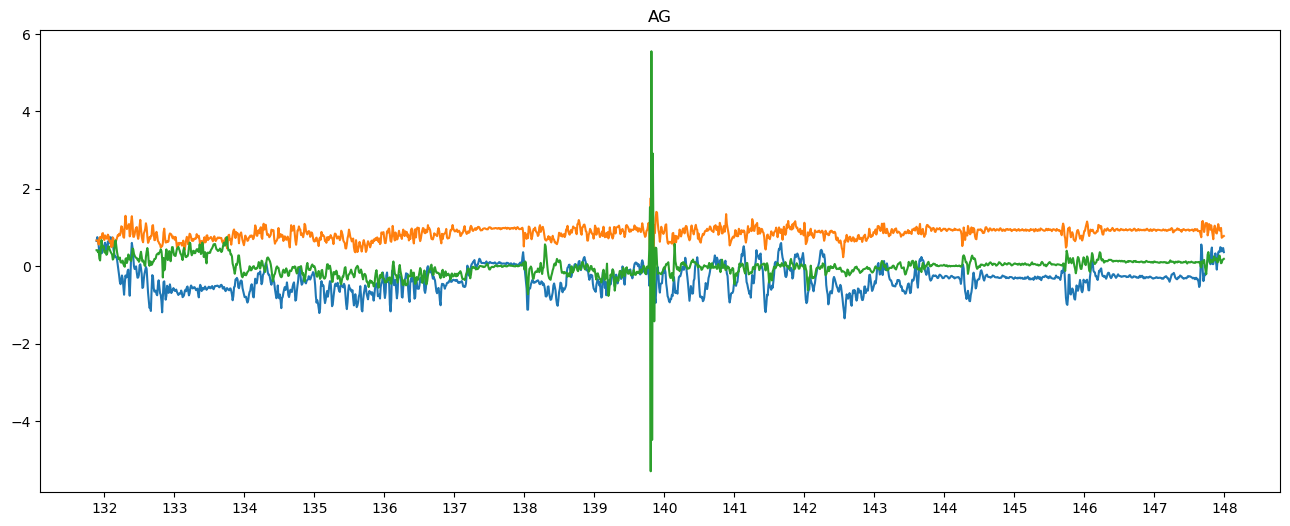

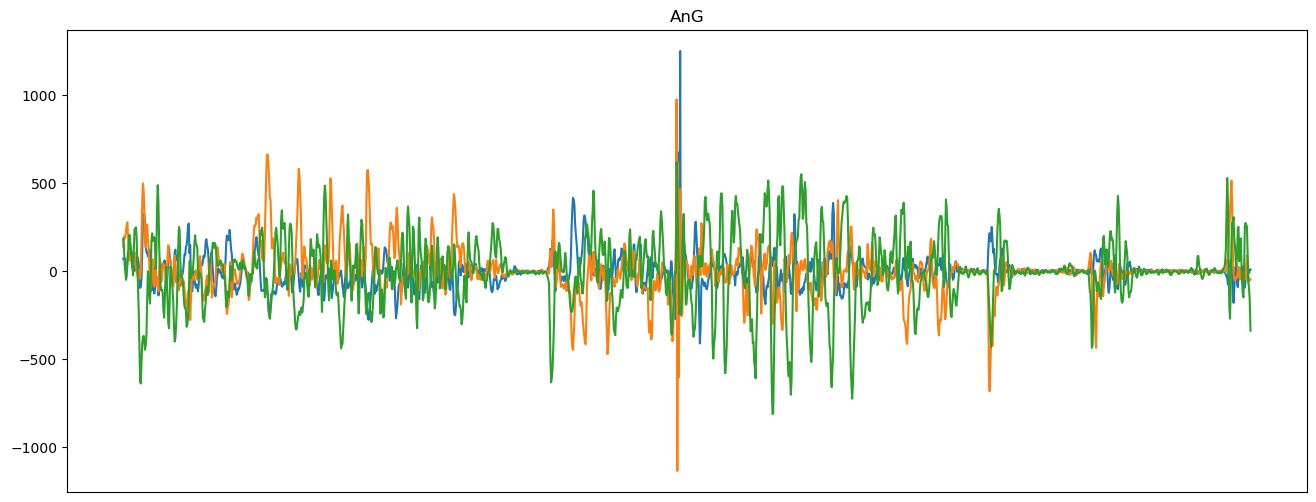

In [269]:
#绘图检查时间和视频对应关系
%matplotlib inline
import matplotlib.pyplot as plt
s = 124
e = 140


start = s*100
end = e*100
figsize = (16, 6)

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(ta[start:end], sig1[start:end,0])
ax.plot(ta[start:end], sig1[start:end,1])
ax.plot(ta[start:end], sig1[start:end,2])
ax.xaxis.set_major_locator(plt.MultipleLocator(1))  # 间隔改为1
plt.title("AG")
plt.show()

fig, ax = plt.subplots()
ax.figure.set_size_inches(figsize)
ax.plot(t_new1[start:end], sig1[start:end,3])
ax.plot(t_new1[start:end], sig1[start:end,4])
ax.plot(t_new1[start:end], sig1[start:end,5])
ax.xaxis.set_major_locator(plt.MultipleLocator(200))
plt.title("AnG")
plt.show()

In [50]:
#数据预处理
import numpy as np

def preprocess_segment(data):
    """
    单段 9 轴 IMU 预处理。
    
    输入
    ----
    data : np.ndarray, shape (n, 9)
        列顺序: [ax, ay, az, wx, wy, wz, roll, pitch, yaw]
        单位: 加速度(g), 角速度(°/s), 角度(°)
        
    输出
    ----
    np.ndarray, shape (n, 12)
        列顺序: [aGx, aGy, aGz, anGx, anGy, anGz, wx, wy, wz, roll, pitch, yaw]
    """
    a_raw = data[:, 0:3].astype(float)
    w_raw = data[:, 3:6].astype(float)
    r_deg = data[:, 6:9].astype(float)

    # 1. 陀螺仪零偏：整段中位数（角速度理论上均值为0）
    w = w_raw - np.median(w_raw, axis=0)

    # 2. 欧拉角 -> 旋转矩阵 R (head -> Earth, ZYX 内旋: yaw→pitch→roll)
    #    如果传感器角度顺序不同，请修改此矩阵
    r = np.radians(r_deg)
    cr, sr = np.cos(r[:, 0]), np.sin(r[:, 0])   # roll
    cp, sp = np.cos(r[:, 1]), np.sin(r[:, 1])   # pitch
    cy, sy = np.cos(r[:, 2]), np.sin(r[:, 2])   # yaw

    R = np.zeros((len(data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr
    R[:, 2, 2] = cp * cr

    # 3. 头部参考系中的重力分量 aG = R^T · [0, 0, 1]
    aG = np.einsum('nij,j->ni', R.transpose(0, 2, 1), np.array([0., 0., 1.]))

    # 验证：aG 模长必须恒为 1.0。若报错，说明角度顺序/定义与代码不符
    assert np.allclose(np.linalg.norm(aG, axis=1), 1.0, atol=0.05), \
        "aG 模长不恒为 1g，请检查 roll/pitch/yaw 是否为 ZYX 内旋顺序"

    # 4. 加速度零偏：利用 anG 应近似零均值的特性
    #    a_raw = aG + anG_true + bias  =>  a_raw - aG = anG_true + bias
    #    取中位数即可分离出 bias（假设真实运动加速度 anG_true 的中位数为0）
    acc_bias = np.median(a_raw - aG, axis=0)
    a = a_raw - acc_bias

    # 5. 非重力加速度
    anG = a - aG
    list_new = np.concatenate([aG, anG, w, r_deg], axis=1)

    return list_new

imu_preprocessed1 = preprocess_segment(imu_a)
imu_preprocessed2 = preprocess_segment(imu_b)

In [51]:
#将数据切割为30s的片段

def segmentation(t, imu):
    data_seg = []
    t_seg = []
    seg_len = 60
    edges = np.arange(t[0] // seg_len * seg_len, t[-1] + seg_len, seg_len)
    ix = np.searchsorted(t, edges)

    for s, e in zip(ix, ix[1:]):
        if e <= s: continue
        ti, imui = t[s:e], imu[s:e]
        data_seg.append(imui)
        t_seg.append(ti)
    return data_seg, t_seg


seg_data1, seg_t1 = segmentation(ta_p, imu_preprocessed1)


In [52]:
print(len(seg_t1[0]))
print(len(seg_data1[0]))

5263
5263


In [94]:
import numpy as np
import ruptures as rpt

def compute_global_gamma(seg_list):
    """
    从多个片段（如前三段）中计算全局稳定的 gamma。
    seg_list: list of np.ndarray, each (n, 12)
    """
    # 合并所有片段的 aG + ω
    all_signal = []
    for seg in seg_list:
        signal_cpd = np.concatenate([seg[:, 0:3], seg[:, 6:9]], axis=1)
        all_signal.append(signal_cpd)
    
    full_signal = np.vstack(all_signal)
    
    # z-score
    mu = np.mean(full_signal, axis=0)
    sigma = np.std(full_signal, axis=0) + 1e-12
    signal_z = (full_signal - mu) / sigma
    
    # 基于总方差的稳定 gamma
    total_var = np.sum(np.var(signal_z, axis=0))
    gamma = 1.0 / total_var if total_var > 0 else 1.0
    
    return gamma

def search_penalty_for_target_duration(data, gamma, sr=100.0, min_size=10, target_ms=377.0):
    """
    搜索 penalty，使得中位段长接近目标时长（毫秒）。
    返回最优 penalty 和对应的中位段长（毫秒）。
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return 0.1, n_samples / sr * 1000.0
    
    # 准备 CPD 输入信号
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    # 目标段长（样本数）
    target_len = target_ms / 1000.0 * sr
    
    # 在 log 空间搜索 penalty
    penalties = np.logspace(-1, 2, 30)  # 0.1 ~ 100
    best_pen = penalties[0]
    best_err = np.inf
    best_med_ms = None
    
    for pen in penalties:
        algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
        algo.fit(signal_z)
        bkps = algo.predict(pen=pen)
        
        # 计算各段长度
        seg_lengths = [bkps[i] - bkps[i-1] for i in range(1, len(bkps))]
        if len(seg_lengths) == 0:
            continue
        
        med_len = np.median(seg_lengths)
        med_ms = med_len / sr * 1000.0
        err = abs(med_ms - target_ms)
        
        if err < best_err:
            best_err = err
            best_pen = pen
            best_med_ms = med_ms
    
    return best_pen, best_med_ms


def dissect_imu_single(data, gamma, penalty, sr=100.0, min_size=10):
    """
    单段 CPD，使用给定的全局 gamma 和 penalty。
    """
    n_samples = len(data)
    if n_samples < 2 * min_size:
        return [data]
    
    signal_cpd = np.concatenate([data[:, 0:3], data[:, 6:9]], axis=1)
    mu = np.mean(signal_cpd, axis=0)
    sigma = np.std(signal_cpd, axis=0) + 1e-12
    signal_z = (signal_cpd - mu) / sigma
    
    algo = rpt.KernelCPD(kernel="rbf", params={"gamma": gamma}, min_size=min_size)
    algo.fit(signal_z)
    bkps = algo.predict(pen=penalty)
    
    segments = []
    start = 0
    for end in bkps:
        if end - start >= min_size:
            segments.append(data[start:end, :])
        start = end
    
    return segments



global_gamma = compute_global_gamma([seg_data1[1], seg_data1[2], seg_data1[3]])
print(f"Global gamma = {global_gamma:.4f}")


penalty_377, med_ms = search_penalty_for_target_duration(
    seg_data1[1], 
    gamma=global_gamma, 
    sr= fs1, 
    min_size=10, 
    target_ms=377.0
)
print(f"搜索到的 penalty = {penalty_377:.2f}, 中位段长 = {med_ms:.1f} ms")

data1_CPDsegments = []
for index in range(1, 10):
    segs = dissect_imu_single(seg_data1[index], gamma=global_gamma, penalty=6.2, sr=fs1, min_size=10)
    data1_CPDsegments.extend(segs)
    print(f"Segment {index}: {len(segs)} sub-segs")

all_lengths = [len(seg) / 100.0 * 1000.0 for seg in data1_CPDsegments]
print(f"全局中位段长: {np.median(all_lengths):.1f} ms")

Global gamma = 0.1667
搜索到的 penalty = 5.74, 中位段长 = 412.9 ms
Segment 1: 96 sub-segs
Segment 2: 91 sub-segs
Segment 3: 80 sub-segs
Segment 4: 85 sub-segs
Segment 5: 75 sub-segs
Segment 6: 73 sub-segs
Segment 7: 87 sub-segs
Segment 8: 68 sub-segs
Segment 9: 80 sub-segs
全局中位段长: 550.0 ms


In [96]:

print(len(seg_t1[0]))
print(np.vstack(seg_data1)[5263])

5263
[ 3.31733076e-01  8.65057745e-01  3.76335308e-01  2.94602275e-01
  6.84270329e-02  7.48595007e-03 -1.95920000e+01 -1.99828997e+02
 -1.32440013e+01  6.64890000e+01 -1.93740000e+01 -9.17079999e+01]


In [97]:
print(f"总片段数: {len(data1_CPDsegments)}")
print(f"每个片段长度: {[len(s) for s in data1_CPDsegments]}")
y = [len(s) for s in data1_CPDsegments]
print(sum(y))
t1_CPDsegments = ta_p[len(seg_t1[0]):len(seg_t1[0]) +sum(y)]
#t1_CPDsegments = ta_p[0:sum(y)]
plt.plot(t1_CPDsegments[400:900],np.vstack(data1_CPDsegments)[400:900,0:3])
plt.show()

总片段数: 735
每个片段长度: [53, 17, 87, 11, 64, 77, 183, 66, 25, 53, 62, 24, 21, 23, 22, 83, 46, 12, 104, 58, 187, 37, 39, 103, 75, 41, 125, 107, 22, 68, 25, 82, 72, 220, 50, 13, 58, 10, 40, 83, 189, 18, 272, 92, 92, 18, 90, 52, 104, 19, 27, 17, 31, 41, 110, 143, 44, 27, 26, 36, 81, 16, 83, 36, 86, 19, 36, 15, 69, 60, 26, 73, 90, 18, 138, 81, 32, 178, 44, 138, 44, 30, 93, 13, 29, 59, 33, 23, 65, 36, 41, 33, 32, 67, 13, 31, 82, 14, 40, 70, 26, 18, 78, 48, 29, 109, 134, 75, 107, 23, 137, 15, 47, 22, 91, 38, 71, 91, 10, 118, 93, 127, 73, 29, 26, 116, 261, 55, 79, 55, 18, 129, 39, 152, 54, 52, 27, 22, 75, 127, 26, 115, 13, 55, 10, 157, 34, 249, 20, 13, 37, 73, 11, 71, 20, 86, 11, 149, 13, 43, 24, 13, 57, 68, 21, 90, 37, 79, 50, 89, 41, 30, 13, 135, 67, 62, 151, 41, 35, 23, 86, 47, 39, 100, 39, 35, 177, 85, 50, 55, 20, 81, 44, 137, 60, 79, 136, 117, 39, 27, 38, 92, 25, 58, 101, 102, 192, 161, 33, 38, 37, 161, 34, 72, 102, 69, 17, 98, 37, 150, 59, 61, 33, 148, 86, 81, 61, 270, 28, 84, 25, 20, 33, 21,

C:\Users\Shubai\AppData\Local\Temp\ipykernel_28024\3286660356.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [98]:
#提取240维特征
import numpy as np
from numpy.linalg import norm

def extract_features(seg_data, fs=100):
    channels = []
    feats = []
    aG = seg_data[:, 0:3].astype(float)
    anG = seg_data[:,3:6].astype(float)
    w = seg_data[:, 6:9].astype(float)
    angles = seg_data[:, 9:12].astype(float)
    
    for ch in range(9):
        x = seg_data[:, ch]
        channels +=  [x]
    
    for ch in range(9):
        x = seg_data[:, ch]
        gradx = np.gradient(x, 1/fs)
        channels += [gradx]
    
    norm_w = np.linalg.norm(seg_data[:, 6:9], axis=1)
    norm_ang = np.linalg.norm(seg_data[:, 3:6], axis=1)
    channels += [norm_w, norm_ang]
    #构建20类数据
    
    for ch in channels:
        mean = np.mean(ch)
        std = np.std(ch)
        max = np.max(ch)
        min = np.min(ch)
        median = np.median(ch)
        q25 = np.percentile(ch, 25)
        q75 = np.percentile(ch, 75)             
        feats += [mean, std, min, max, median, q25, q75]
    #提取20维数据的7个特征，共140个特征

    duration = seg_data.shape[0]/ fs
    log_duration = np.log10(duration)
    feats += [duration, log_duration]
    #每段时长与对数时长，2维

    corr = np.corrcoef(seg_data[:, 3:9].T)[np.triu_indices(6, k=1)]
    feats += corr.tolist()
    #Ω和AnG的两两相关性，15维

    energy_w = np.sum(np.square(seg_data[:, 6:9]))
    energy_anG = np.sum(np.square(seg_data[:, 3:6]))
    feats += [energy_w, energy_anG]
    #AnG和w的信号能量，2维 

    for ch in range(9):
        x = seg_data[:, ch]
        zeropass = np.sum((x[:-1] * x[1:]) < 0)
        feats += [zeropass]
    #所有通道的过零次数，9维

    
    r = np.radians(angles)
    cr = np.cos(r[:, 0]);  sr_roll = np.sin(r[:, 0])   # roll
    cp = np.cos(r[:, 1]);  sp = np.sin(r[:, 1])       # pitch
    cy = np.cos(r[:, 2]);  sy = np.sin(r[:, 2])       # yaw

    # 3. 构建旋转矩阵 R (head -> Earth, ZYX 内旋)
    R = np.zeros((len(seg_data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr_roll - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr_roll
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr_roll + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr_roll
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr_roll
    R[:, 2, 2] = cp * cr

    w_E = np.einsum('nij,nj->ni', R, w)
    w_Ez = w_E[:, 2]



    cum_az = np.cumsum(w_Ez)/100
    mean = np.mean(cum_az)
    std = np.std(cum_az)
    min = np.min(cum_az)
    max = np.max(cum_az)
    median = np.median(cum_az)
    q25 = np.percentile(cum_az, 25)
    q75 = np.percentile(cum_az, 75) 
    net_az = np.sum(w_Ez) /100
    net_az_speed = np.sum(w_Ez) / (len(w_Ez) / fs)   # 或 np.sum(w_Ez) / duration
    feats += [mean, std, min, max, median, q25, q75, net_az, net_az_speed] 
    #重力极化参考系陀螺仪方位特征，13维


    aG = seg_data[:, 0:3].astype(float)
    angles = seg_data[:, 9:12].astype(float)

    # 初始/最终重力向量坐标
    aG_first = aG[0, :]
    aG_last = aG[-1, :]

    # 重力向量坐标变化
    aG_delta = aG_last - aG_first
    # 头部倾斜总变化 (度)
    tilt_change = np.arccos(np.clip(np.dot(aG_first, aG_last), -1.0, 1.0))
    # 头部倾斜净变化速度
    tilt_change_speed = tilt_change / duration

    # 3D 航向：旋转矩阵 R (head->Earth) 的第一列，即 R @ [1,0,0]
    r = np.radians(angles)
    cr = np.cos(r[:, 0]); sr_roll = np.sin(r[:, 0])
    cp = np.cos(r[:, 1]); sp = np.sin(r[:, 1])
    cy = np.cos(r[:, 2]); sy = np.sin(r[:, 2])

    R = np.zeros((len(seg_data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr_roll - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr_roll
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr_roll + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr_roll
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr_roll
    R[:, 2, 2] = cp * cr

    heading = R[:, :, 0]          # 每行是一个 3D heading 向量
    heading_first = heading[0, :]
    heading_last = heading[-1, :]
    # 3D 航向总变化
    heading_change = np.arccos(np.clip(np.dot(heading_first, heading_last), -1.0, 1.0))
    # 3D 航向净变化速度
    heading_change_speed = heading_change / duration
    feats += [aG_first[0], aG_first[1], aG_first[2], aG_last[0], aG_last[1], aG_last[2], aG_delta[0], aG_delta[1], aG_delta[2], tilt_change, tilt_change_speed, heading_change, heading_change_speed]
    #头部倾斜与 3D 航向特征，13维

        # ========== vMF 均值方向与离散度 (8维) ==========
    aG = seg_data[:, 0:3].astype(float)

    # head tilt 单位向量
    aG_norm = aG / (np.linalg.norm(aG, axis=1, keepdims=True) + 1e-12)

    # 3D heading 已在上一步计算: heading = R[:, :, 0]

    def vmf_mean_disp(vectors):
        mean_vec = np.mean(vectors, axis=0)
        R_bar = np.linalg.norm(mean_vec)
        mu = mean_vec / (R_bar + 1e-12)
        if R_bar > 0.999:
            kappa = 1e6
        else:
            kappa = R_bar * (3.0 - R_bar**2) / (1.0 - R_bar**2 + 1e-12)
        dispersion = 1.0 / np.sqrt(kappa + 1e-12)
        return mu, dispersion

    mu_tilt, disp_tilt = vmf_mean_disp(aG_norm)
    mu_head, disp_head = vmf_mean_disp(heading)

    feats += [
        mu_tilt[0], mu_tilt[1], mu_tilt[2], disp_tilt,
        mu_head[0], mu_head[1], mu_head[2], disp_head
    ]
    # ========== CWT 时频特征 (42维) ==========
    sr = 100.0

    signals = [
        seg_data[:, 3], seg_data[:, 4], seg_data[:, 5],
        seg_data[:, 6], seg_data[:, 7], seg_data[:, 8]
    ]

    freqs = np.logspace(0, np.log10(20), 20)
    band_edges = np.linspace(2.5, 20, 8)
    freq_band = np.digitize(freqs, band_edges) - 1
    freq_band = np.clip(freq_band, 0, 6)

    n_cycles = 5
    feats_cwt = []

    for sig in signals:
        n = len(sig)
        t_offset = (np.arange(n) - n // 2) / sr
        
        coeff_mags = np.zeros((20, n))
        for i, f in enumerate(freqs):
            sigma_t = n_cycles / (2.0 * np.pi * f)
            wavelet = np.exp(2j * np.pi * f * t_offset) * np.exp(-t_offset**2 / (2.0 * sigma_t**2))
            wavelet = wavelet / (np.sum(np.abs(wavelet)) + 1e-12)
            conv = np.convolve(sig, wavelet, mode='same')
            coeff_mags[i, :] = np.abs(conv)
        
        for b in range(7):
            mask = freq_band == b
            if np.any(mask):
                band_mean = np.mean(coeff_mags[mask, :], axis=0)
                med = np.median(band_mean)
            else:
                med = 0.0
            feats_cwt.append(np.log10(med + 1e-12))

    feats += feats_cwt

    return feats


In [ ]:
# 退阶版特征提取
# """
# 6轴IMU数据特征提取模块
# 基于 Fayat et al. (2025) DISSeCT 框架的特征工程方法

# 文章参考:
# - 输入数据: 6轴IMU原始数据 (3轴加速度 + 3轴陀螺仪), 不解算姿态角
# - 特征设计灵感: 文中提取240维特征的方法，包括统计特征(statistics on aG, anG, ω)
#   和时频属性(time-frequency attributes of anG and ω)
# - 关键生理频段（根据文章）:
#   * 5-7 Hz: 快速运动(locomotion/trotting)节律
#   * 8.5-11 Hz: 嗅觉探索(sniffing)节律
#   * 16-20 Hz: 甩水(wet dog shake)高频振荡
# - 实现说明: 本文使用FFT-based频域特征替代原文CWT，以降低计算成本并保持可解释性

# 作者: AI Assistant
# """

# import numpy as np
# from scipy import stats
# from scipy.fft import rfft, rfftfreq
# from typing import List, Tuple


# def extract_time_features(x: np.ndarray) -> dict:
#     """
#     提取单轴时域统计特征
#     对应文章中的 "multiple statistics on ... signals"
#     """
#     features = {}
#     features['mean'] = np.mean(x)
#     features['std'] = np.std(x)
#     features['var'] = np.var(x)
#     features['min'] = np.min(x)
#     features['max'] = np.max(x)
#     features['ptp'] = np.ptp(x)                       # peak-to-peak
#     features['rms'] = np.sqrt(np.mean(x**2))         # root mean square
#     features['mad'] = np.mean(np.abs(x - np.mean(x))) # mean absolute deviation
#     features['skew'] = stats.skew(x)                  # 偏度
#     features['kurt'] = stats.kurtosis(x)              # 峰度
#     features['energy'] = np.sum(x**2)                # 信号能量
#     features['zcr'] = np.sum(np.diff(np.signbit(x).astype(int)) != 0) / len(x)  # 过零率
#     return features


# def extract_freq_features(x: np.ndarray, fs: float) -> dict:
#     """
#     提取单轴频域特征 (基于FFT)
#     对应文章中的 "time-frequency attributes" 和 "continuous wavelet transforms"

#     关键频段定义（根据文章 Fig 3, Fig 4, Fig 5, 第29页）:
#     - band_5_7:   快速运动 locomotion 主频段 (trotting step cycle)
#     - band_85_11: 嗅觉探索 sniffing 主频段 (sniffing signature)
#     - band_16_20: 甩水 wet dog shake 高频段
#     """
#     n = len(x)
#     if n < 2:
#         return {k: 0.0 for k in [
#             'dom_freq', 'spec_energy', 'spec_entropy', 'spec_centroid', 
#             'spec_bw', 'max_amp',
#             'band_05_4', 'band_4_8', 'band_5_7', 'band_8_12', 
#             'band_85_11', 'band_12_20', 'band_16_20', 'band_20_50'
#         ]}

#     yf = rfft(x)
#     xf = rfftfreq(n, 1/fs)
#     ps = np.abs(yf)**2          # 功率谱

#     total_energy = np.sum(ps) + 1e-12

#     # 主频率 (dominant frequency)
#     dom_idx = np.argmax(ps)
#     features = {}
#     features['dom_freq'] = xf[dom_idx] if dom_idx < len(xf) else 0.0

#     # 频谱能量
#     features['spec_energy'] = total_energy

#     # 频谱熵 (spectral entropy)
#     ps_norm = ps / total_energy
#     features['spec_entropy'] = -np.sum(ps_norm * np.log2(ps_norm + 1e-12))

#     # 频谱质心 (spectral centroid)
#     features['spec_centroid'] = np.sum(xf * ps) / total_energy

#     # 频谱带宽 (spectral bandwidth, RMS)
#     features['spec_bw'] = np.sqrt(np.sum(((xf - features['spec_centroid'])**2) * ps) / total_energy)

#     # 最大幅值
#     features['max_amp'] = np.max(ps)

#     # 频段相对能量 (relative band powers)
#     # 注意: 频段边界根据 fs/2 自动截断，避免奈奎斯特频率以上
#     nyq = fs / 2 - 0.1
#     bands = {
#         'band_05_4':  (0.5, 4.0),      # 极低频/静止相关
#         'band_4_8':   (4.0, 8.0),      # 包含 locomotion 频段
#         'band_5_7':   (5.0, 7.0),      # locomotion 主频段 (Fig 3)
#         'band_8_12':  (8.0, 12.0),     # 包含 sniffing 频段
#         'band_85_11': (8.5, 11.0),     # sniffing 主频段 (Fig 4, 第29页)
#         'band_12_20': (12.0, 20.0),    # 包含 wet dog shake 频段
#         'band_16_20': (16.0, 20.0),    # wet dog shake 主频段 (S5 Fig)
#         'band_20_50': (20.0, min(50.0, nyq))  # 高频段
#     }

#     for name, (low, high) in bands.items():
#         idx = (xf >= low) & (xf < high)
#         features[name] = np.sum(ps[idx]) / total_energy if np.any(idx) else 0.0

#     return features


# def extract_cross_features(seg: np.ndarray, fs: float) -> dict:
#     """
#     提取交叉轴特征与模值特征
#     对应文章中的 "directional information" 和轴间耦合特征
#     """
#     features = {}

#     # 加速度轴间相关系数 (反映头部姿态耦合)
#     for i, j in [(0,1), (0,2), (1,2)]:
#         c = np.corrcoef(seg[:, i], seg[:, j])[0, 1] if len(seg) > 1 else 0.0
#         features[f'acc_corr_{i}{j}'] = c

#     # 陀螺仪轴间相关系数 (反映旋转耦合，如文章Fig 5A中 grooming 的 roll-yaw 耦合)
#     for i, j in [(0,1), (0,2), (1,2)]:
#         c = np.corrcoef(seg[:, 3+i], seg[:, 3+j])[0, 1] if len(seg) > 1 else 0.0
#         features[f'gyro_corr_{i}{j}'] = c

#     # 加速度-陀螺仪对应轴相关系数
#     for i in range(3):
#         c = np.corrcoef(seg[:, i], seg[:, 3+i])[0, 1] if len(seg) > 1 else 0.0
#         features[f'cross_corr_{i}'] = c

#     # 模值 (magnitude) 统计特征
#     acc_norm = np.linalg.norm(seg[:, :3], axis=1)
#     gyro_norm = np.linalg.norm(seg[:, 3:], axis=1)

#     for prefix, arr in [('acc_norm', acc_norm), ('gyro_norm', gyro_norm)]:
#         features[f'{prefix}_mean'] = np.mean(arr)
#         features[f'{prefix}_std'] = np.std(arr)
#         features[f'{prefix}_max'] = np.max(arr)
#         features[f'{prefix}_rms'] = np.sqrt(np.mean(arr**2))
#         features[f'{prefix}_energy'] = np.sum(arr**2)

#     # 模值频域特征 (关键频段能量比，用于捕捉整体运动节律)
#     if len(seg) > 1:
#         for prefix, arr in [('acc_norm', acc_norm), ('gyro_norm', gyro_norm)]:
#             yf = rfft(arr)
#             ps = np.abs(yf)**2
#             total = np.sum(ps) + 1e-12
#             xf = rfftfreq(len(arr), 1/fs)
#             for bname, (low, high) in [
#                 ('5_7', (5.0, 7.0)), 
#                 ('85_11', (8.5, 11.0)), 
#                 ('16_20', (16.0, 20.0))
#             ]:
#                 idx = (xf >= low) & (xf < high)
#                 features[f'{prefix}_band_{bname}'] = np.sum(ps[idx]) / total if np.any(idx) else 0.0
#     else:
#         for prefix in ['acc_norm', 'gyro_norm']:
#             for bname in ['5_7', '85_11', '16_20']:
#                 features[f'{prefix}_band_{bname}'] = 0.0

#     return features


# def extract_imu_features(segments: List[np.ndarray], fs: float = 300.0) -> Tuple[np.ndarray, List[str]]:
#     """
#     从分段6轴IMU数据中提取完整特征向量

#     参数:
#         segments: list of np.ndarray, 每个元素形状为 (n_samples, 6)
#                   列顺序: [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
#                   n_samples 可为变长（不同段长度可以不同）
#         fs: 采样率 (Hz), 默认300Hz (与文章大鼠实验一致)

#     返回:
#         features: np.ndarray, 形状 (n_segments, n_features)
#                   每行对应一个段的特征向量
#         feature_names: list of str, 特征名称列表

#     特征构成 (共181维):
#     - 逐轴时域统计: 6轴 × 12 = 72
#     - 逐轴频域特征: 6轴 × 14 = 84
#     - 交叉轴相关: 9
#     - 模值时域: 2 × 5 = 10
#     - 模值频域: 2 × 3 = 6
#     """
#     all_features = []
#     feature_names = None
#     axis_names = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

#     for x in segments:
#         seg = x[:,0:6]
#         if seg.ndim != 2 or seg.shape[1] != 6:
#             raise ValueError(f"每段数据必须是2维数组且列数为6, 当前形状: {seg.shape}")

#         seg_feats = {}

#         # 1. 逐轴时域与频域特征
#         for i, name in enumerate(axis_names):
#             x = seg[:, i]
#             tfeats = extract_time_features(x)
#             for k, v in tfeats.items():
#                 seg_feats[f'{name}_{k}'] = v

#             ffeats = extract_freq_features(x, fs)
#             for k, v in ffeats.items():
#                 seg_feats[f'{name}_{k}'] = v

#         # 2. 交叉轴与模值特征
#         cfeats = extract_cross_features(seg, fs)
#         seg_feats.update(cfeats)

#         if feature_names is None:
#             feature_names = list(seg_feats.keys())

#         all_features.append([seg_feats[k] for k in feature_names])

#     return np.array(all_features), feature_names






In [99]:
#降维
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def dim_reduction(features, PCs=30):
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    pca = PCA(n_components=PCs)
    features_pca = pca.fit_transform(features_scaled)
    
    # 分析前 5 个 PC 的主要高贡献特征
    n_top = min(5, PCs)
    top_features = {}
    
    for i in range(n_top):
        # 第 i 个主成分中各原始特征的权重
        weights = pca.components_[i]
        # 按绝对值从大到小排序，取前 5 个特征索引
        top5_idx = np.argsort(np.abs(weights))[::-1][:5]
        top_features[f'PC{i+1}'] = top5_idx.tolist()
        print(f"PC{i+1} 高贡献特征序号: {top5_idx.tolist()}")
    
    return features_pca


#运行提取、降维



# features= extract_features(data1_CPDsegments, fs=fs1)
# features_pca, topfeatures = dim_reduction(features)



In [100]:
features =  []
for s in data1_CPDsegments:
    feat = extract_features(s, fs=100)
    features.append(feat)

features_pca = dim_reduction(features)

PC1 高贡献特征序号: [139, 133, 232, 231, 137]
PC2 高贡献特征序号: [59, 187, 141, 66, 189]
PC3 高贡献特征序号: [38, 45, 100, 62, 158]
PC4 高贡献特征序号: [177, 0, 190, 196, 6]
PC5 高贡献特征序号: [174, 175, 168, 49, 172]


最优: K=4, cov=diag, BIC=88854.3


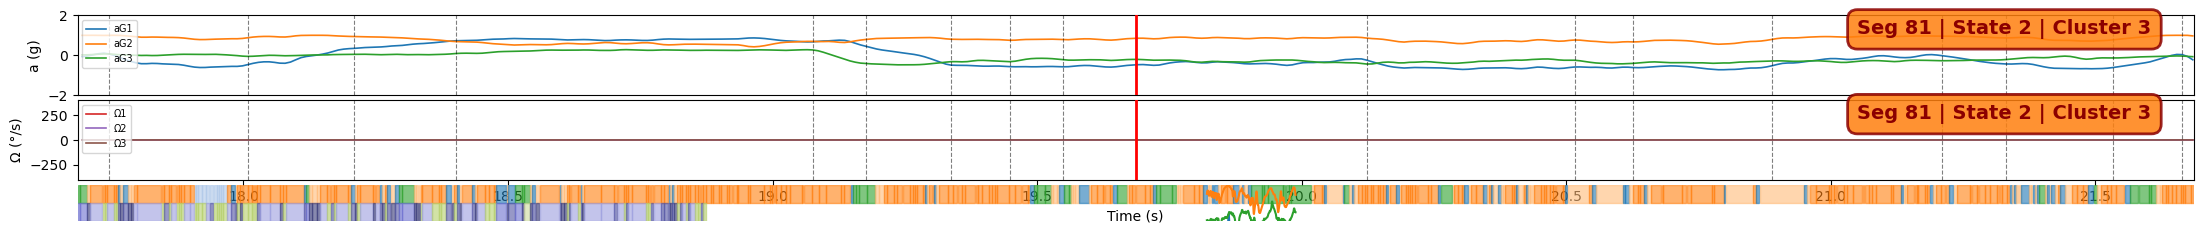

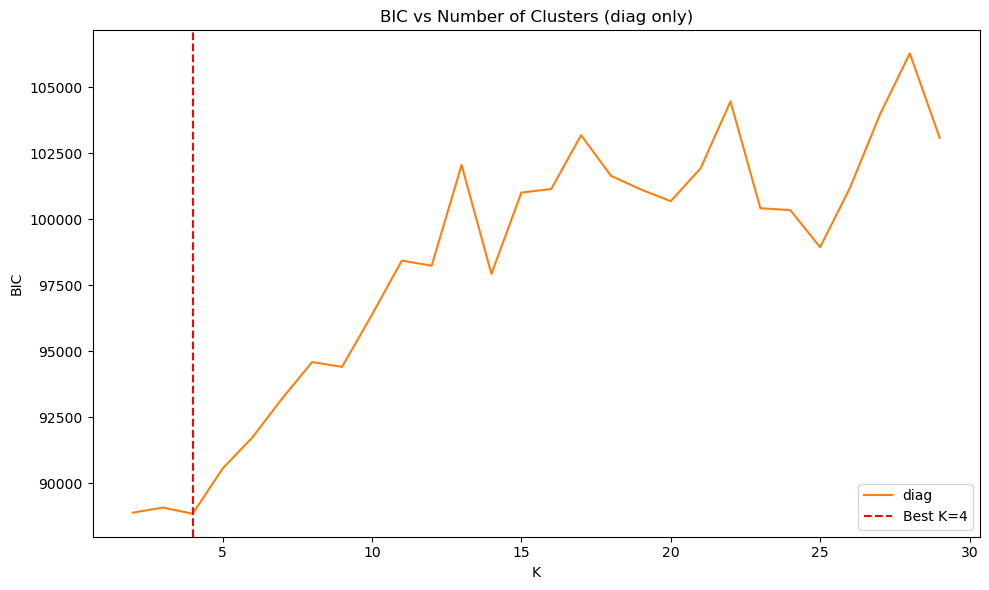

In [101]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

# 输入: X_pca (n_segments, n_features)
X_pca = features_pca

# 1. BIC 搜索，仅 diag

K_range = range(2, 30)
best_bic = np.inf
best_gmm = None
bics = []

for K in K_range:
    gmm = GaussianMixture(
        n_components=K,
        covariance_type='full',
        n_init=10,
        random_state=0
    )
    gmm.fit(X_pca)
    bic = gmm.bic(X_pca)
    bics.append(bic)
    
    if bic < best_bic:
        best_bic = bic
        best_gmm = gmm

labels = best_gmm.predict(X_pca)
print(f"最优: K={best_gmm.n_components}, cov=diag, BIC={best_bic:.1f}")

# 2. 绘制 BIC 曲线
plt.figure(figsize=(10, 6))
plt.plot(K_range, bics, color='tab:orange', label='diag')
plt.axvline(best_gmm.n_components, color='red', linestyle='--', label=f'Best K={best_gmm.n_components}')
plt.xlabel('K')
plt.ylabel('BIC')
plt.title('BIC vs Number of Clusters (diag only)')
plt.legend()
plt.tight_layout()
plt.show()


d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


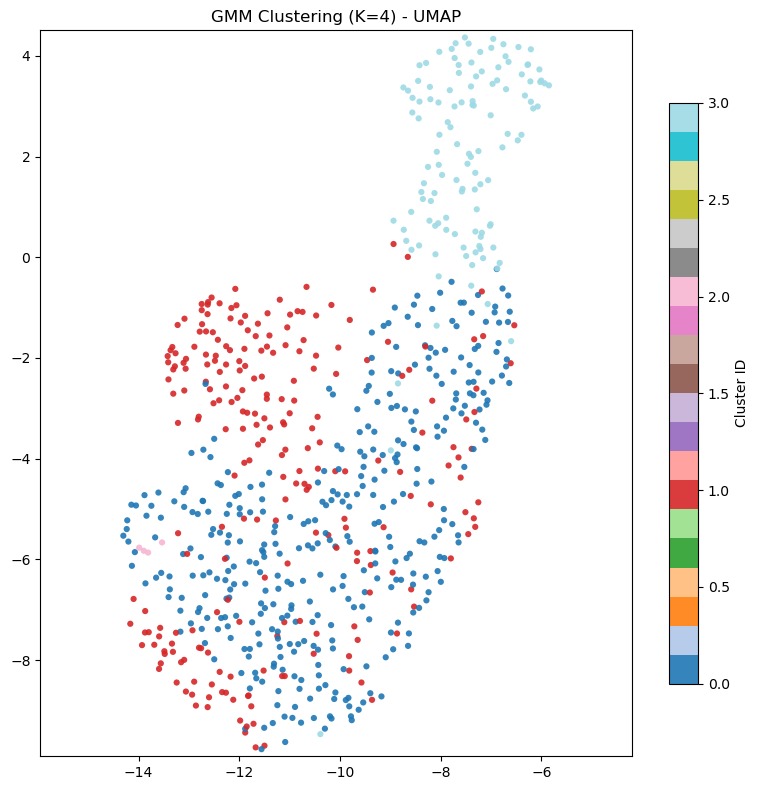

In [102]:
# UMAP 可视化：更小、实心、更紧凑
%matplotlib inline
reducer_umap = umap.UMAP(n_neighbors=10,
                        min_dist=0.5, 
                        random_state=40,
                        spread = 1.0)
X_umap = reducer_umap.fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    X_umap[:, 0], 
    X_umap[:, 1], 
    c=labels, 
    cmap='tab20'[0:5], 
    s=20,              # 点更小
    marker='o',       # 实心圆
    linewidths=0,     # 无描边
    edgecolors='none',
    alpha=0.9
)

# 收紧坐标轴，消除空白边距，使图像更紧凑
ax.margins(0.01)
ax.set_aspect('equal', adjustable='datalim')

plt.colorbar(scatter, label='Cluster ID', shrink=0.8)
plt.title(f'GMM Clustering (K={best_gmm.n_components}) - UMAP')
plt.tight_layout()
plt.show()

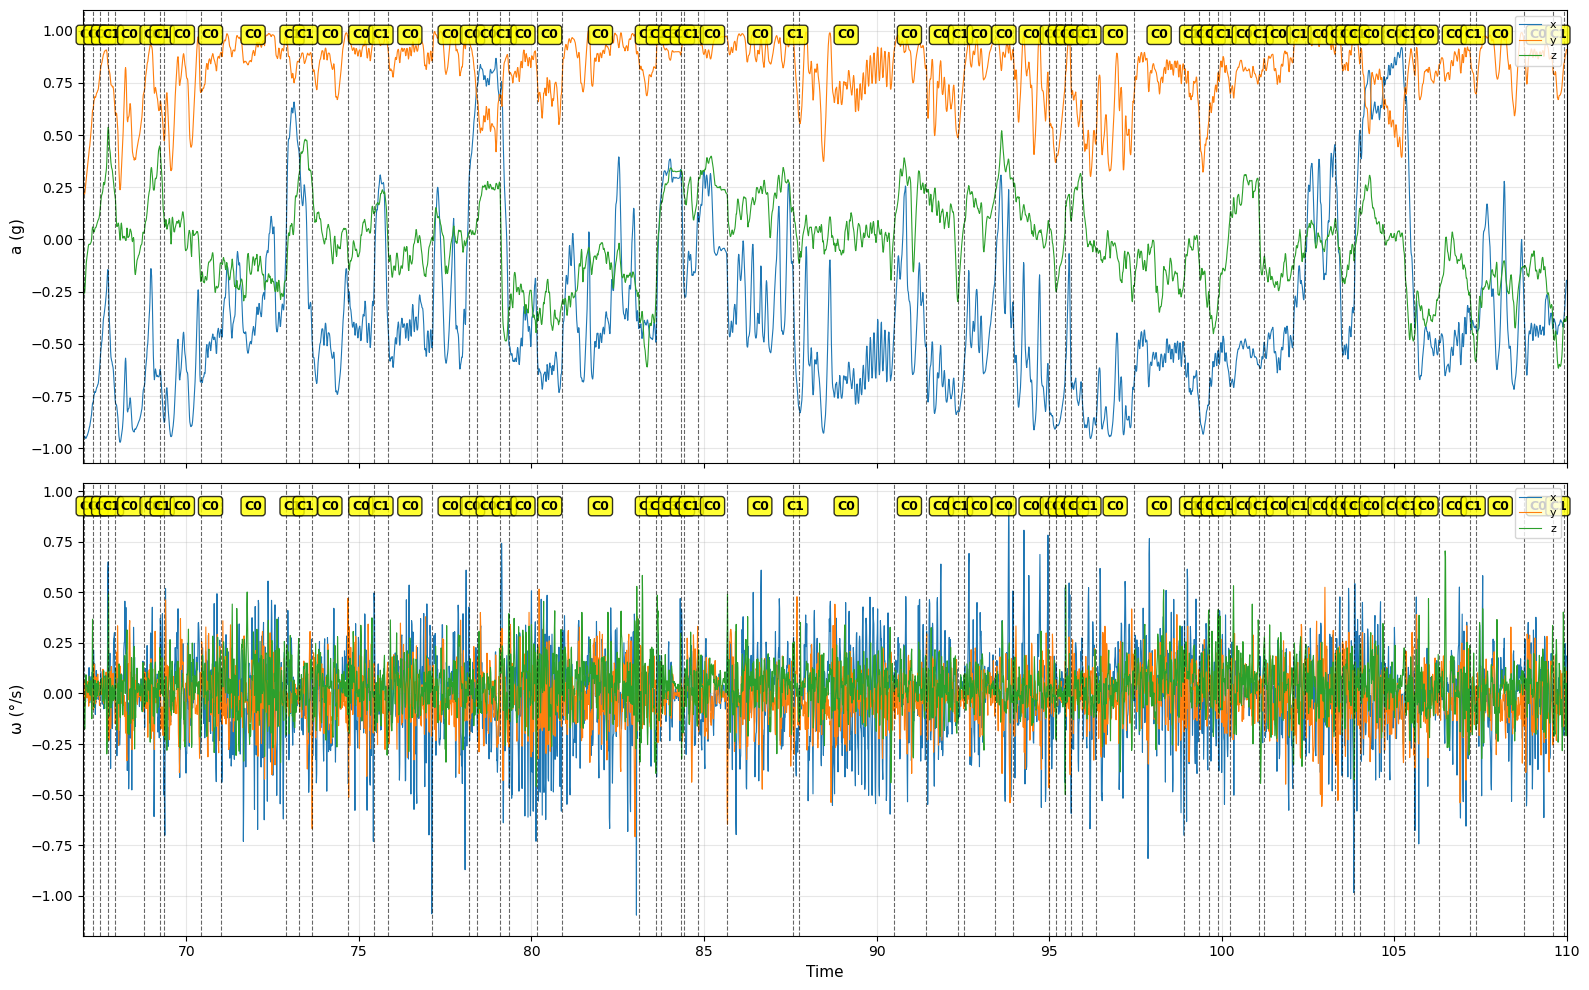

In [105]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def plot_segments_with_labels(data_segments, timestamps, labels, 
                               t_start=None, t_end=None, 
                               figsize=(16, 10)):
    """
    绘制分段 IMU 数据，按时间戳截断，虚线分隔片段，并标注类别。
    
    参数
    ----
    data_segments : list of np.ndarray
        每段 (m, 12)，列顺序: [aGx,aGy,aGz, anGx,anGy,anGz, wx,wy,wz, roll,pitch,yaw]
    timestamps : np.ndarray
        连续时间戳，长度等于所有段样本数之和
    labels : np.ndarray or list
        每段对应的类标签
    t_start, t_end : float or None
        绘制的时间范围（单位与 timestamps 一致）。None 表示全部绘制。
    figsize : tuple
        图像尺寸
    """
    # 1. 拼接完整数据
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    
    # 2. 时间截断
    if t_start is None:
        t_start = full_times[0]
    if t_end is None:
        t_end = full_times[-1]
    
    idx0 = np.searchsorted(full_times, t_start)
    idx1 = np.searchsorted(full_times, t_end)
    idx0 = max(0, idx0)
    idx1 = min(len(full_times), idx1)
    
    times = full_times[idx0:idx1]
    data = full_data[idx0:idx1, :]
    
    # 3. 计算每段在全局时间中的起止（只保留与视图有交集的）
    seg_starts = []
    seg_ends = []
    seg_labels_view = []
    
    cumsum = 0
    for i, seg in enumerate(data_segments):
        seg_len = len(seg)
        seg_t0 = full_times[cumsum]
        seg_t1 = full_times[cumsum + seg_len - 1] if seg_len > 1 else full_times[cumsum]
        
        if seg_t1 >= t_start and seg_t0 <= t_end:
            seg_starts.append(seg_t0)
            seg_ends.append(seg_t1)
            seg_labels_view.append(int(labels[i]))
        
        cumsum += seg_len
    
    # 4. 绘图
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    groups = [
        (data[:, 0:3], 'a (g)', ['x', 'y', 'z']),
        (data[:, 3:6], 'ω (°/s)', ['x', 'y', 'z']),
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for ax, (d, title, ch_names) in zip(axes, groups):
        # 画三通道曲线
        for ch in range(3):
            ax.plot(times, d[:, ch], color=colors[ch], lw=0.8, label=ch_names[ch])
        
        # 画虚线边界
        for t_b in seg_starts:
            if t_start <= t_b <= t_end:
                ax.axvline(t_b, color='black', linestyle='--', lw=0.8, alpha=0.6)
        
        # 标注类别：在片段中点上方，黄底黑字
        y_top = ax.get_ylim()[1]
        for t0, t1, lab in zip(seg_starts, seg_ends, seg_labels_view):
            mid = (t0 + t1) / 2
            if t_start <= mid <= t_end:
                ax.text(mid, y_top * 0.92, f'C{lab}', 
                        ha='center', va='top', fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='yellow', alpha=0.8))
        
        ax.set_ylabel(title, fontsize=11)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(t_start, t_end)
    
    axes[-1].set_xlabel('Time', fontsize=11)
    plt.tight_layout()
    plt.show()


# ========== 使用示例 ==========
plot_segments_with_labels(
    data_segments= data1_CPDsegments,      # list of (m, 12)
    timestamps=t1_CPDsegments,         # (n_total,)
    labels=labels,                 # (n_segments,)
    t_start=67,                       # 从第 0 秒开始
    t_end=110,                       # 画前 30 秒
    figsize=(16, 10)
)

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

def fit_categorical_hmm_bic(labels, K, S_max=15, n_restarts=10):
    """
    按照原文方法拟合分类 HMM，通过 BIC 选择最优隐藏状态数 S。
    
    参数
    ----
    labels : np.ndarray, shape (N,)
        观测序列，每个元素为 0..K-1 的整数（cluster 标签）
    K : int
        观测类别数（clusters 数）
    S_max : int
        隐藏状态数搜索上限（原文 1–30）
    n_restarts : int
        每个 S 的随机初始化次数（原文 10 次）
        
    返回
    ----
    best_model : hmm.CategoricalHMM
    best_S : int
    best_bic : float
    state_sequence : np.ndarray, shape (N,)
        Viterbi 解码后的最优隐藏状态序列
    """
    # 确保输入格式
    Y = np.asarray(labels).flatten()
    if Y.min() < 0 or Y.max() >= K:
        raise ValueError("labels must be integers in range [0, K-1]")
    X = Y.reshape(-1, 1)
    N = len(Y)
    
    best_bic = -np.inf
    best_model = None
    best_S = None
    
    print("Searching optimal S via BIC...")
    for S in range(1, S_max + 1):
        bic_scores = []
        models = []
        
        for r in range(n_restarts):
            # 原文：100 次 EM 迭代，随机初始化
            model = hmm.CategoricalHMM(
                n_components=S,
                n_features=K,
                n_iter=100,
                random_state=None,
                init_params='ste'
            )
            try:
                model.fit(X)
                log_likelihood = model.score(X)
                
                # 参数数量 m_S（原文公式）
                # startprob: S-1, transmat: S*(S-1), emissionprob: S*(K-1)
                m_S = (S - 1) + S * (S - 1) + S * (K - 1)
                
                # BIC = 2*logL - m_S*log(N)
                bic = 2 * log_likelihood - m_S * np.log(N)
                bic_scores.append(bic)
                models.append(model)
            except Exception:
                bic_scores.append(-np.inf)
                models.append(None)
        
        idx_best = int(np.argmax(bic_scores))
        bic_best_S = bic_scores[idx_best]
        print(f"  S={S:2d}: best BIC={bic_best_S:.1f}")
        
        if bic_best_S > best_bic:
            best_bic = bic_best_S
            best_model = models[idx_best]
            best_S = S
    
    # Viterbi 解码（原文 E-step）
    state_sequence = best_model.predict(X)
    
    print(f"\nOptimal: S={best_S}, BIC={best_bic:.1f}")
    return best_model, best_S, best_bic, state_sequence


def visualize_hmm(model, labels, K, best_S, state_sequence, figsize=(14, 10)):
    """
    HMM 结果可视化，贴近原文 Fig 6 风格。
    """
    Y = np.asarray(labels).flatten()
    N = len(Y)
    
    E = model.emissionprob_          # (S, K)
    A = model.transmat_              # (S, S)
    
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2], hspace=0.35, wspace=0.3)
    
    # ---------- 子图 1: 发射概率矩阵 (类似 Fig 6A) ----------
    ax1 = fig.add_subplot(gs[0, :])
    im1 = ax1.imshow(E, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax1.set_xlabel('Cluster ID', fontsize=11)
    ax1.set_ylabel('Hidden State', fontsize=11)
    ax1.set_title('Emission Probabilities  P(cluster | state)', fontsize=12, fontweight='bold')
    ax1.set_xticks(np.arange(K))
    ax1.set_yticks(np.arange(best_S))
    plt.colorbar(im1, ax=ax1, label='Probability')
    
    for i in range(best_S):
        for j in range(K):
            if E[i, j] > 0.15:
                ax1.text(j, i, f'{E[i,j]:.2f}', ha='center', va='center', 
                        color='white' if E[i,j] > 0.6 else 'black', fontsize=7)
    
    # ---------- 子图 2: 转移矩阵 (类似 Fig 6B) ----------
    ax2 = fig.add_subplot(gs[1, 0])
    im2 = ax2.imshow(A, aspect='auto', cmap='Greys', vmin=0, vmax=1)
    ax2.set_xlabel('To State', fontsize=11)
    ax2.set_ylabel('From State', fontsize=11)
    ax2.set_title('State Transition Matrix', fontsize=12, fontweight='bold')
    ax2.set_xticks(np.arange(best_S))
    ax2.set_yticks(np.arange(best_S))
    plt.colorbar(im2, ax=ax2, label='Probability')
    
    # ---------- 子图 3: 每个状态的主导 Cluster ----------
    ax3 = fig.add_subplot(gs[1, 1])
    dominant_clusters = np.argmax(E, axis=1)
    dominant_probs = np.max(E, axis=1)
    
    y_pos = np.arange(best_S)
    ax3.barh(y_pos, dominant_probs, color='steelblue', edgecolor='black')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([f'State {i}' for i in range(best_S)])
    ax3.set_xlabel('Max Emission Probability', fontsize=11)
    ax3.set_title('Dominant Cluster per State', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1)
    
    for i, (prob, clus) in enumerate(zip(dominant_probs, dominant_clusters)):
        ax3.text(prob + 0.02, i, f'C{clus}', va='center', fontsize=9, fontweight='bold')
    
    # ---------- 子图 4: 状态序列与观测序列 (类似 Fig 6D) ----------
    ax4 = fig.add_subplot(gs[2, :])
    
    show_n = min(N, 800)
    t = np.arange(show_n)
    
    ax4.scatter(t, Y[:show_n], c='lightgray', s=12, alpha=0.5, label='Cluster (GMM)', zorder=1)
    ax4.step(t, state_sequence[:show_n], where='mid', color='darkred', lw=2, label='Hidden State (HMM)', zorder=2)
    
    ax4.set_xlabel('Segment Index', fontsize=11)
    ax4.set_ylabel('State / Cluster ID', fontsize=11)
    ax4.set_title('State Sequence (Viterbi Decoding)', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.set_ylim(-0.5, max(best_S, K) - 0.5)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.show()
    
    # 打印映射表
    print("\n--- State-Cluster Mapping ---")
    for i in range(best_S):
        top3 = np.argsort(E[i])[::-1][:3]
        probs = E[i, top3]
        print(f"State {i:2d}: top clusters = {top3} (probs: {probs.round(3)})")


# ========== 使用示例 ==========
# 确保 labels 是 0-based 整数
if labels.min() != 0:
    labels = labels - labels.min()

best_model, best_S, best_bic, state_seq = fit_categorical_hmm_bic(
    labels=labels, 
    K=10, 
    S_max=7, 
    n_restarts=10
)


Searching optimal S via BIC...
  S= 1: best BIC=-12646.1
  S= 2: best BIC=-11200.7
  S= 3: best BIC=-10915.4
  S= 4: best BIC=-10520.7
  S= 5: best BIC=-10487.6
  S= 6: best BIC=-10561.0
  S= 7: best BIC=-10717.6

Optimal: S=5, BIC=-10487.6


C:\Users\Shubai\AppData\Local\Temp\ipykernel_28024\628857744.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


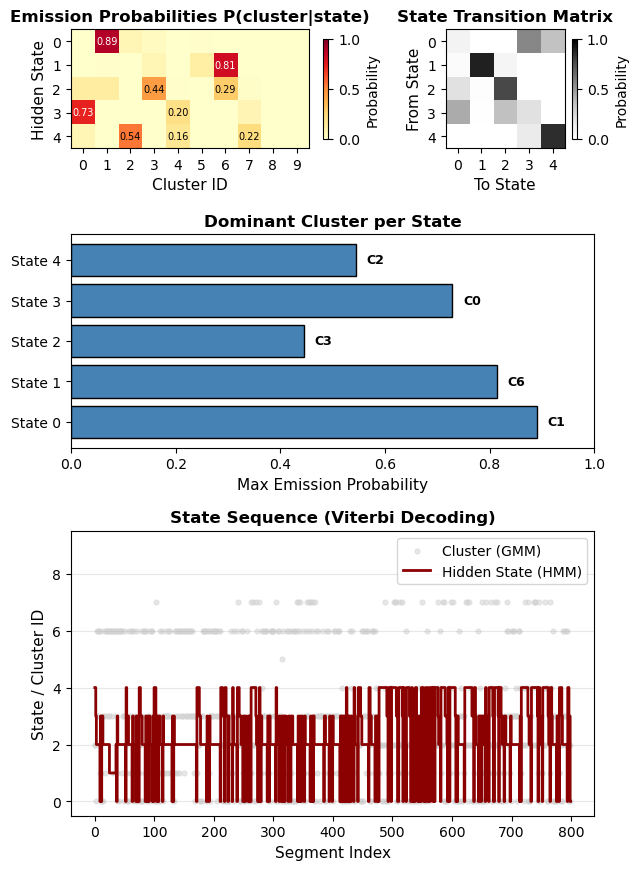


--- State-Cluster Mapping ---
State  0: top clusters = [1 2 3] (probs: [0.891 0.068 0.032])
State  1: top clusters = [6 5 3] (probs: [0.815 0.113 0.064])
State  2: top clusters = [3 6 1] (probs: [0.444 0.289 0.123])
State  3: top clusters = [0 4 7] (probs: [0.729 0.2   0.071])
State  4: top clusters = [2 7 4] (probs: [0.544 0.223 0.164])


In [73]:
%matplotlib inline

def visualize_hmm(model, labels, K, best_S, state_sequence, cell_size=0.35):
    """
    HMM 结果可视化，保持矩阵原始比例（方形单元格），不纵向压缩。
    布局：发射矩阵与转移矩阵并排（各自单元格为正方形），
          主导图与序列图在下侧展开。
    """
    Y = np.asarray(labels).flatten()
    N = len(Y)
    E = model.emissionprob_
    A = model.transmat_
    
    # 动态 figsize：根据数据维度计算，确保单元格接近正方形
    # 发射矩阵 E: 宽 K, 高 S  |  转移矩阵 A: 宽 S, 高 S
    w0 = K * cell_size
    w1 = best_S * cell_size
    h0 = best_S * cell_size
    h1 = max(best_S * cell_size * 0.4, 3)
    h2 = 4
    
    fig = plt.figure(figsize=(w0 + w1 + 1.5, h0 + h1 + h2 + 1.5))
    gs = fig.add_gridspec(3, 2, 
                          width_ratios=[w0, w1], 
                          height_ratios=[h0, h1, h2],
                          hspace=0.4, wspace=0.35)
    
    # ---------- 子图 1: 发射概率矩阵 (S, K) ----------
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(E, aspect='equal', cmap='YlOrRd', vmin=0, vmax=1)
    ax1.set_xlabel('Cluster ID', fontsize=11)
    ax1.set_ylabel('Hidden State', fontsize=11)
    ax1.set_title('Emission Probabilities P(cluster|state)', fontsize=12, fontweight='bold')
    ax1.set_xticks(np.arange(K))
    ax1.set_yticks(np.arange(best_S))
    plt.colorbar(im1, ax=ax1, label='Probability', shrink=0.8)
    
    for i in range(best_S):
        for j in range(K):
            if E[i, j] > 0.15:
                ax1.text(j, i, f'{E[i,j]:.2f}', ha='center', va='center', 
                        color='white' if E[i,j] > 0.6 else 'black', fontsize=7)
    
    # ---------- 子图 2: 转移矩阵 (S, S) 方形 ----------
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(A, aspect='equal', cmap='Greys', vmin=0, vmax=1)
    ax2.set_xlabel('To State', fontsize=11)
    ax2.set_ylabel('From State', fontsize=11)
    ax2.set_title('State Transition Matrix', fontsize=12, fontweight='bold')
    ax2.set_xticks(np.arange(best_S))
    ax2.set_yticks(np.arange(best_S))
    plt.colorbar(im2, ax=ax2, label='Probability', shrink=0.8)
    
    # ---------- 子图 3: 主导 Cluster（跨两列） ----------
    ax3 = fig.add_subplot(gs[1, :])
    dominant_clusters = np.argmax(E, axis=1)
    dominant_probs = np.max(E, axis=1)
    y_pos = np.arange(best_S)
    ax3.barh(y_pos, dominant_probs, color='steelblue', edgecolor='black')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([f'State {i}' for i in range(best_S)])
    ax3.set_xlabel('Max Emission Probability', fontsize=11)
    ax3.set_title('Dominant Cluster per State', fontsize=12, fontweight='bold')
    ax3.set_xlim(0, 1)
    for i, (prob, clus) in enumerate(zip(dominant_probs, dominant_clusters)):
        ax3.text(prob + 0.02, i, f'C{clus}', va='center', fontsize=9, fontweight='bold')
    
    # ---------- 子图 4: 状态序列（跨两列） ----------
    ax4 = fig.add_subplot(gs[2, :])
    show_n = min(N, 800)
    t = np.arange(show_n)
    ax4.scatter(t, Y[:show_n], c='lightgray', s=12, alpha=0.5, label='Cluster (GMM)', zorder=1)
    ax4.step(t, state_sequence[:show_n], where='mid', color='darkred', lw=2, label='Hidden State (HMM)', zorder=2)
    ax4.set_xlabel('Segment Index', fontsize=11)
    ax4.set_ylabel('State / Cluster ID', fontsize=11)
    ax4.set_title('State Sequence (Viterbi Decoding)', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.set_ylim(-0.5, max(best_S, K) - 0.5)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # 打印映射表
    print("\n--- State-Cluster Mapping ---")
    for i in range(best_S):
        top3 = np.argsort(E[i])[::-1][:3]
        probs = E[i, top3]
        print(f"State {i:2d}: top clusters = {top3} (probs: {probs.round(3)})")


# ========== 使用示例 ==========
# best_model, best_S, best_bic, state_seq = fit_categorical_hmm_bic(
#     labels=labels, K=11, S_max=15, n_restarts=10
# )
# visualize_hmm(best_model, labels, 11, best_S, state_seq, cell_size=0.35)
visualize_hmm(best_model, labels, 10, best_S, state_seq)

In [80]:
import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def crop_video_and_data(video_path, data_segments, timestamps, duration_sec=120.0):
    """
    按 IMU 时间戳起点对齐，裁剪视频和前 duration_sec 秒的 IMU 数据。
    """
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    
    t_start = full_times[0]
    t_end_crop = t_start + duration_sec
    
    idx_end = np.searchsorted(full_times, t_end_crop)
    idx_end = min(idx_end, len(full_times))
    
    cropped_segments = []
    total_samples = 0
    for seg in data_segments:
        seg_len = len(seg)
        if total_samples >= idx_end:
            break
        if total_samples + seg_len <= idx_end:
            cropped_segments.append(seg)
        else:
            cropped_segments.append(seg[:idx_end - total_samples])
        total_samples += seg_len
    
    cropped_times = full_times[:idx_end]
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    frame_start = max(0, int(np.floor(t_start * fps)))
    frame_end = min(total_frames, int(np.ceil(t_end_crop * fps)) + 1)
    n_frames_crop = frame_end - frame_start
    
    if frame_start > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_start)
    
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    name, ext = os.path.splitext(base_name)
    cropped_video_path = os.path.join(dir_name, f"{name}_2min_aligned{ext}")
    
    out = cv2.VideoWriter(cropped_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    for _ in tqdm(range(n_frames_crop), desc="Cropping video"):
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)
    
    out.release()
    cap.release()
    print(f"Saved: {cropped_video_path}")
    return cropped_video_path, cropped_segments, cropped_times

import os
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def render_hmm_cluster_video(video_path, data_segments, timestamps, 
                             state_sequence, cluster_labels,
                             window_sec=4.0, step=2, plot_dpi=80):
    """
    将 HMM 隐藏状态 和 GMM 聚类类别 同时合成到视频上。
    若 state_sequence / cluster_labels 长度超过 data_segments，自动截取前 N 段。
    """
    # ===== 截取标签：只保留与 data_segments 对应的片段 =====
    n_segs = len(data_segments)
    state_sequence = np.asarray(state_sequence)[:n_segs]
    cluster_labels = np.asarray(cluster_labels)[:n_segs]
    
    full_data = np.vstack(data_segments)
    full_times = np.asarray(timestamps).flatten()
    full_times = full_times - full_times[0]
    n_total = len(full_times)
    
    S = int(np.max(state_sequence)) + 1
    K = int(np.max(cluster_labels)) + 1
    
    # 计算每段起止时间
    seg_info = []
    idx = 0
    for i, seg in enumerate(data_segments):
        m = len(seg)
        seg_info.append({
            'start_idx': idx,
            'end_idx': idx + m,
            't_start': full_times[idx],
            't_end': full_times[idx + m - 1] if m > 1 else full_times[idx],
            'state': int(state_sequence[i]),
            'cluster': int(cluster_labels[i]),
            'seg_id': i
        })
        idx += m
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    t_start = 0.0
    t_end = full_times[-1]
    frame_start = 0
    frame_end = total_frames
    
    dir_name = os.path.dirname(video_path)
    base_name = os.path.basename(video_path)
    out_path = os.path.join(dir_name, "hmm_cluster_" + base_name)
    
    wave_h = 320
    progress_h = 80
    total_plot_h = wave_h + progress_h
    
    out_fps = fps / step
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), out_fps, (w, h + total_plot_h))
    
    half = window_sec / 2.0
    
    # 预计算每帧对应的 segment
    n_frames = frame_end - frame_start
    frame_times_all = (np.arange(frame_start, frame_end) + 0.5) / fps
    
    seg_starts = np.array([s['t_start'] for s in seg_info])
    seg_ends = np.array([s['t_end'] for s in seg_info])
    seg_states_arr = np.array([s['state'] for s in seg_info])
    seg_clusters_arr = np.array([s['cluster'] for s in seg_info])
    seg_ids_arr = np.array([s['seg_id'] for s in seg_info])
    
    frame_seg_idx = np.searchsorted(seg_starts, frame_times_all, side='right') - 1
    frame_seg_idx = np.clip(frame_seg_idx, 0, len(seg_info) - 1)
    valid_mask = (frame_times_all >= seg_starts[frame_seg_idx]) & (frame_times_all <= seg_ends[frame_seg_idx])
    frame_seg_idx[~valid_mask] = -1
    
    # 颜色映射
    cmap_state = plt.cm.get_cmap('tab20', max(S, 20))
    cmap_cluster = plt.cm.get_cmap('tab20b', max(K, 20))
    state_colors = {s: cmap_state(i) for i, s in enumerate(sorted(set(seg_states_arr)))}
    cluster_colors = {k: cmap_cluster(i) for i, k in enumerate(sorted(set(seg_clusters_arr)))}
    
    process_frames = np.arange(frame_start, frame_end, step)
    
    for fi in tqdm(process_frames, desc="Rendering", total=len(process_frames)):
        t = fi / fps
        
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            continue
        
        # IMU 窗口
        i0 = np.searchsorted(full_times, t - half)
        i1 = np.searchsorted(full_times, t + half)
        i0 = max(0, i0)
        i1 = min(n_total, i1)
        tw = full_times[i0:i1]
        dw = full_data[i0:i1, :]
        if len(tw) < 2:
            continue
        
        # 查当前 segment
        seg_idx = frame_seg_idx[fi - frame_start]
        if seg_idx >= 0:
            curr_state = int(seg_states_arr[seg_idx])
            curr_cluster = int(seg_clusters_arr[seg_idx])
            curr_seg_id = int(seg_ids_arr[seg_idx])
        else:
            curr_state = -1
            curr_cluster = -1
            curr_seg_id = -1
        
        # 绘制
        fig = plt.figure(figsize=(w / 150, total_plot_h / 150), dpi=plot_dpi)
        gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.45], hspace=0.08)
        
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
        
        # --- aG 1-3 ---
        colors_aG = ['#1f77b4', '#ff7f0e', '#2ca02c']
        for ch in range(3):
            ax1.plot(tw, dw[:, ch], color=colors_aG[ch], lw=1.2, label=f'aG{ch+1}')
        ax1.axvline(t, color='red', lw=2, zorder=5)
        for s in seg_info:
            if t - half <= s['t_start'] <= t + half:
                ax1.axvline(s['t_start'], color='black', linestyle='--', lw=0.8, alpha=0.5)
        ax1.set_xlim(t - half, t + half)
        ax1.set_ylim(-2, 2)
        ax1.set_ylabel('a (g)', fontsize=10)
        ax1.set_xticks([])
        ax1.legend(loc='upper left', fontsize=7)
        
        # --- 角度 7-9 ---
        colors_ang = ['#d62728', '#9467bd', '#8c564b']
        for ch in range(3):
            ax2.plot(tw, dw[:, ch + 6], color=colors_ang[ch], lw=1.2, label=f'Ω{ch+1}')
        ax2.axvline(t, color='red', lw=2, zorder=5)
        for s in seg_info:
            if t - half <= s['t_start'] <= t + half:
                ax2.axvline(s['t_start'], color='black', linestyle='--', lw=0.8, alpha=0.5)
        ax2.set_xlim(t - half, t + half)
        ax2.set_ylim(-400, 400)
        ax2.set_ylabel('Ω (°/s)', fontsize=10)
        ax2.set_xlabel('Time (s)', fontsize=10)
        ax2.legend(loc='upper left', fontsize=7)
        
        # --- 大标签：同时显示 State + Cluster ---
        if curr_state >= 0:
            state_color = state_colors.get(curr_state, 'yellow')
            label_text = f"Seg {curr_seg_id} | State {curr_state} | Cluster {curr_cluster}"
            for ax in [ax1, ax2]:
                ax.text(
                    0.98, 0.95, label_text,
                    transform=ax.transAxes,
                    fontsize=14, color='darkred', fontweight='bold',
                    ha='right', va='top',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=state_color, alpha=0.85,
                              edgecolor='darkred', linewidth=2)
                )
        
        # --- 底部双层滚动条 ---
        ax3.set_xlim(t_start, t_end)
        ax3.set_ylim(0, 1)
        ax3.axis('off')
        
        # 上层：HMM State（y=0.5~1.0）
        for s in seg_info:
            color = state_colors.get(s['state'], 'gray')
            ax3.axvspan(s['t_start'], s['t_end'], ymin=0.5, ymax=1.0, 
                        color=color, alpha=0.6, zorder=1)
        
        # 下层：GMM Cluster（y=0.0~0.5）
        for s in seg_info:
            color = cluster_colors.get(s['cluster'], 'gray')
            ax3.axvspan(s['t_start'], s['t_end'], ymin=0.0, ymax=0.5, 
                        color=color, alpha=0.6, zorder=1)
        
        # 当前窗口高亮
        ax3.axvspan(t - half, t + half, color='white', alpha=0.25, zorder=2)
        ax3.axvline(t, color='red', lw=2, zorder=5)
        
        # 图例文字
        ax3.text(t_start + (t_end - t_start) * 0.02, 0.75, 'HMM State', 
                 fontsize=9, va='center', color='white', fontweight='bold')
        ax3.text(t_start + (t_end - t_start) * 0.02, 0.25, 'GMM Cluster', 
                 fontsize=9, va='center', color='white', fontweight='bold')
        
        ax3.set_xticks(np.linspace(t_start, t_end, 5))
        ax3.set_xticklabels([f'{x:.1f}s' for x in np.linspace(t_start, t_end, 5)], fontsize=8)
        
        fig.canvas.draw()
        
        buf = fig.canvas.buffer_rgba()
        plot_img = np.frombuffer(buf, dtype=np.uint8)
        plot_img = plot_img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        plot_img = plot_img[:, :, :3]
        plot_img = cv2.cvtColor(plot_img, cv2.COLOR_RGB2BGR)
        plt.close(fig)
        
        if plot_img.shape[1] != w or plot_img.shape[0] != total_plot_h:
            plot_img = cv2.resize(plot_img, (w, total_plot_h))
        
        combined = np.vstack([frame, plot_img])
        out.write(combined)
    
    out.release()
    cap.release()
    print(f"Saved: {out_path}")
    return out_path

In [17]:
print(t1_CPDsegments[0])

60.00742014298157


In [78]:
# ========== 使用示例 ==========
# 1. 裁剪前 2 分钟
cropped_video, cropped_segments, cropped_times = crop_video_and_data(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2.mp4",
    data_segments=data1_CPDsegments,
    timestamps=t1_CPDsegments,
    duration_sec=60.0
)




Cropping video: 100%|██████████| 1800/1800 [01:50<00:00, 16.24it/s]

Saved: F:/IMU_computational_ethology/Data/LSD\LSD_data2_2min_aligned.mp4


In [46]:
print(len(cropped_segments))

157


In [81]:

render_hmm_cluster_video(
    video_path=cropped_video,
    data_segments=cropped_segments,
    timestamps=cropped_times,
    state_sequence=state_seq,        # HMM 解码结果 (n_segments,)
    cluster_labels=labels,     # GMM 硬分配结果 (n_segments,)
    window_sec=4.0,
    step=1,
    plot_dpi=100
)


C:\Users\Shubai\AppData\Local\Temp\ipykernel_28024\559582448.py:151: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_state = plt.cm.get_cmap('tab20', max(S, 20))
C:\Users\Shubai\AppData\Local\Temp\ipykernel_28024\559582448.py:152: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cluster = plt.cm.get_cmap('tab20b', max(K, 20))
Rendering:   0%|          | 0/1800 [00:00<?, ?it/s]

Rendering: 100%|██████████| 1800/1800 [18:12<00:00,  1.65it/s]

Saved: F:/IMU_computational_ethology/Data/LSD\hmm_cluster_LSD_data2_2min_aligned.mp4


'F:/IMU_computational_ethology/Data/LSD\\hmm_cluster_LSD_data2_2min_aligned.mp4'

In [87]:
import os
import cv2
import numpy as np
from tqdm.auto import tqdm

def cut_video_by_cluster(video_path, data_segments, timestamps, cluster_labels, output_dir):
    """
    按 Cluster 标签将原始视频切割为片段，分类保存到以 cluster 命名的文件夹中。
    
    参数
    ----
    video_path : str
        原始视频路径
    data_segments : list of np.ndarray
        CPD 后的片段列表，每段 (m, 12)
    timestamps : np.ndarray
        连续时间戳，长度等于所有段样本数之和
    cluster_labels : np.ndarray or list
        每段对应的 cluster 标签，长度等于 len(data_segments)
    output_dir : str
        输出根目录，会在其下创建 "cluster_0", "cluster_1" 等子文件夹
    """
    full_times = np.asarray(timestamps).flatten()
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # 计算每段起止帧
    seg_bounds = []
    idx = 0
    for seg in data_segments:
        m = len(seg)
        t0 = full_times[idx]
        t1 = full_times[idx + m - 1] if m > 1 else full_times[idx]
        
        f0 = max(0, int(np.floor(t0 * fps)))
        f1 = min(total_frames, int(np.ceil(t1 * fps)) + 1)
        seg_bounds.append((f0, f1))
        idx += m
    
    # 创建 cluster 文件夹
    unique_clusters = sorted(set(int(l) for l in cluster_labels))
    for c in unique_clusters:
        os.makedirs(os.path.join(output_dir, f"cluster_{c}"), exist_ok=True)
    
    # 逐段切割
    for i, (lab, (f0, f1)) in enumerate(tqdm(zip(cluster_labels, seg_bounds), total=len(seg_bounds), desc="Cutting")):
        c = int(lab)
        out_dir = os.path.join(output_dir, f"cluster_{c}")
        out_path = os.path.join(out_dir, f"seg_{i:05d}_f{f0:06d}_{f1:06d}.mp4")
        
        # 创建该片段的 writer
        cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
        ret, frame = cap.read()
        if not ret:
            continue
            
        h, w = frame.shape[:2]
        writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
        writer.write(frame)
        
        for _ in range(f1 - f0 - 1):
            ret, frame = cap.read()
            if not ret:
                break
            writer.write(frame)
        
        writer.release()
    
    cap.release()
    print(f"Done. Saved to: {output_dir}")



cut_video_by_cluster(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2_x264.mp4",
    data_segments=data1_CPDsegments,       # list of (m, 12)
    timestamps=t1_CPDsegments,          # (n_total,)
    cluster_labels=labels,        # (n_segments,)
    output_dir="F:/IMU_computational_ethology/Data/LSD/videoclips"
)

Cutting:  33%|███▎      | 1055/3244 [10:27<21:41,  1.68it/s] 


KeyboardInterrupt: 

[[ 3.31733076e-01  8.65057745e-01  3.76335308e-01  2.94602275e-01
   6.84270329e-02  7.48595007e-03 -1.95920000e+01 -1.99828997e+02
  -1.32440013e+01  6.64890000e+01 -1.93740000e+01 -9.17079999e+01]
 [ 3.40674933e-01  8.66215183e-01  3.65529542e-01  2.35660421e-01
   7.26959581e-03 -3.47082863e-02 -2.53899996e+01 -2.62023998e+02
  -6.25610022e+01  6.71210000e+01 -1.99180000e+01 -9.41749999e+01]
 [ 3.44823141e-01  8.68657041e-01  3.55713294e-01  1.08512217e-01
  -1.33172259e-01 -3.68920390e-02 -6.26219986e+01 -3.08167000e+02
  -9.96700040e+01  6.77310000e+01 -2.01710000e+01 -9.74429999e+01]
 [ 3.59084781e-01  8.65948088e-01  3.48126456e-01 -4.17494294e-02
  -2.99463313e-01 -1.30520029e-03 -9.14910000e+01 -2.96692000e+02
   6.15239885e+01  6.80990000e+01 -2.10439999e+01 -1.00646000e+02]
 [ 4.04359556e-01  8.49015275e-01  3.40097651e-01  8.19757928e-02
  -2.18530505e-01 -1.12763956e-02 -5.43820007e+01 -3.34228998e+02
   2.50366996e+02  6.81700000e+01 -2.38509999e+01 -1.02958000e+02]
 [ 4.